In [1]:
import pandas as pd


df=pd.read_csv("../data/raw/complaints.csv")

df.head()

C:\Users\lydia\AppData\Local\Temp\ipykernel_14748\2977040898.py:4: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("../data/raw/complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [2]:

df.shape


df.columns


df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB


In [3]:

product_counts=df["Product"].value_counts()


print(product_counts)


Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

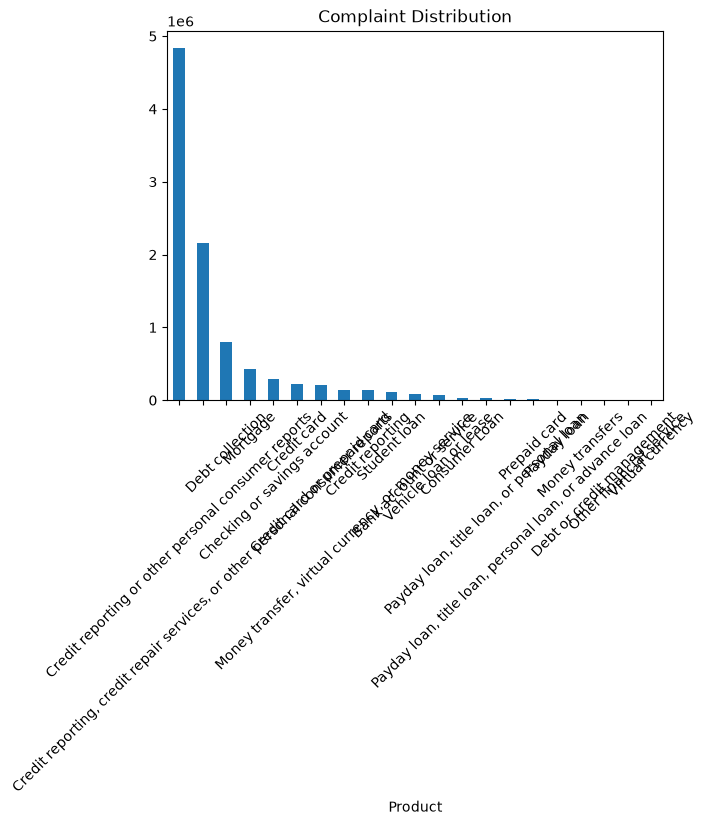

In [4]:

import matplotlib.pyplot as plt


product_counts.plot(kind='bar')


plt.title("Complaint Distribution")


plt.xticks(rotation=45)


plt.show()


In [5]:

df["Consumer complaint narrative"].isnull().sum()


np.int64(6629041)

In [6]:

with_narrative=df["Consumer complaint narrative"].notna().sum()

without_narrative=df["Consumer complaint narrative"].isna().sum()



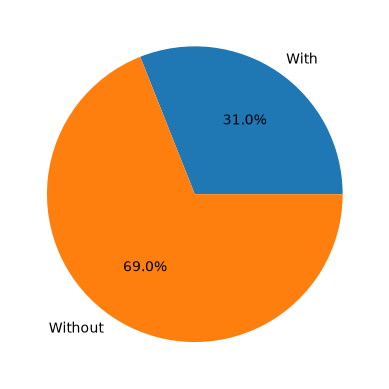

In [7]:

plt.pie(

[with_narrative,without_narrative],

labels=["With","Without"],

autopct="%1.1f%%"

)

plt.show()


In [8]:

df["word_count"]=df["Consumer complaint narrative"]\
.fillna("")\
.apply(lambda x:len(x.split()))


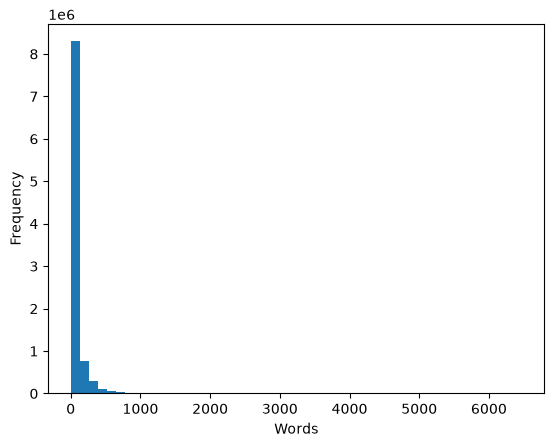

In [9]:


plt.hist(

df["word_count"],

bins=50

)

plt.xlabel("Words")

plt.ylabel("Frequency")


plt.show()


In [10]:

df["word_count"].describe()


count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: word_count, dtype: float64

In [11]:

df["Product"].unique()


<StringArray>
[                         'Credit reporting or other personal consumer reports',
                                                              'Debt collection',
                                                                  'Credit card',
                                                  'Checking or savings account',
                           'Money transfer, virtual currency, or money service',
                                                        'Vehicle loan or lease',
                                                    'Debt or credit management',
                                                                     'Mortgage',
                      'Payday loan, title loan, personal loan, or advance loan',
                                                                 'Prepaid card',
                                                                 'Student loan',
                                                             'Credit reporting',
 'Credit repor

In [12]:

products=[

"Credit card",

"Personal loan",

"Savings account",

"Money transfer"

]


filtered=df[

df["Product"].isin(products)

]


In [13]:

filtered=filtered[

filtered["Consumer complaint narrative"].notna()

]


In [14]:

filtered=filtered[

filtered["Consumer complaint narrative"].str.strip()!=""

]


In [15]:

import re

In [16]:

def clean_text(text):


    text=text.lower()


    text=re.sub(

        r'i am writing to file a complaint.*',

        '',

        text

    )


    text=re.sub(r'[^a-zA-Z\s]',' ',text)


    text=re.sub(r'\s+',' ',text)


    return text.strip()


In [17]:

filtered["cleaned_text"]=filtered[

"Consumer complaint narrative"

].apply(clean_text)


In [18]:

filtered.to_csv(

"../data/processed/filtered_complaints.csv",

index=False

)


In [19]:

df=pd.read_csv(

"../data/processed/filtered_complaints.csv"

)


In [20]:

sample=df.groupby("Product",group_keys=False)\
.apply(

lambda x:

x.sample(

frac=12000/len(df),

random_state=42

)

)


In [21]:

sample=df.groupby("Product").sample(

n=3000,

random_state=42

)


In [22]:
# Change this:
# from langchain.text_splitter import RecursiveCharacterTextSplitter

# To this:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Now your splitter will run perfectly
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

c:\Users\lydia\Desktop\rag-complaint-chatbot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
chunks = []

for idx, row in sample.iterrows():
    text = row["cleaned_text"]
    
    # FIX: Safety check to handle NaN/float values gracefully
    if pd.isna(text) or not isinstance(text, str):
        continue  # Skip this row if it isn't a valid string
        
    parts = splitter.split_text(text)

    for p in parts:
        chunks.append({
            "complaint_id": idx,
            "product": row["Product"],
            "text": p
        })

print(f"Successfully generated {len(chunks)} text chunks for Task 2!")

Successfully generated 8424 text chunks for Task 2!


In [24]:


chunks_df=pd.DataFrame(chunks)


In [25]:

from sentence_transformers import SentenceTransformer


model=SentenceTransformer(

'all-MiniLM-L6-v2'

)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2891.89it/s]


In [26]:


embeddings=model.encode(

chunks_df["text"].tolist(),

show_progress_bar=True

)


Batches: 100%|██████████| 264/264 [01:31<00:00,  2.87it/s]


In [28]:


import chromadb


client=chromadb.PersistentClient(


path="../vector_store"

)


In [29]:


collection=client.get_or_create_collection(

"complaints"

)


In [30]:


for i,row in chunks_df.iterrows():



    collection.add(


        ids=[str(i)],



        documents=[row["text"]],



        embeddings=[embeddings[i].tolist()],



        metadatas=[


        {

        "product":row["product"],


        "complaint_id":

        str(row["complaint_id"])

        }


        ]

    )

